In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("complete_food_nutrition_dataset.csv")
print(df.shape)

(4217, 18)


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4217 entries, 0 to 4216
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   food_name        4217 non-null   object 
 1   protein_g        4209 non-null   float64
 2   fat_g            4197 non-null   float64
 3   carbohydrates_g  4177 non-null   float64
 4   calories_kcal    4197 non-null   float64
 5   water_g          244 non-null    float64
 6   fiber_g          3498 non-null   float64
 7   calcium_mg       3605 non-null   float64
 8   iron_mg          3528 non-null   float64
 9   magnesium_mg     535 non-null    float64
 10  potassium_mg     2907 non-null   float64
 11  sodium_mg        4174 non-null   float64
 12  vitamin_a_ug     471 non-null    float64
 13  vitamin_d_ug     639 non-null    float64
 14  vitamin_c_mg     2557 non-null   float64
 15  vitamin_b12_ug   372 non-null    float64
 16  cholesterol_mg   3474 non-null   float64
 17  sugar_g       

,protein_g,fat_g,carbohydrates_g,calories_kcal,water_g,fiber_g,calcium_mg,iron_mg,magnesium_mg,potassium_mg,sodium_mg,vitamin_a_ug,vitamin_d_ug,vitamin_c_mg,vitamin_b12_ug,cholesterol_mg,sugar_g
count,4209.000000,4197.000000,4177.000000,4197.000000,244.000000,3498.000000,3605.000000,3528.000000,535.000000,2907.000000,4174.000000,471.000000,639.000000,2557.000000,372.000000,3474.000000,4022.000000
mean,8.521313,9.420985,31.566489,241.513106,53.918002,3.584984,91.902002,2.148293,33.349917,307.562287,563.735448,50.854863,0.469406,96.654782,1.114709,146.098752,12.040868
std,13.834201,17.887224,50.126737,255.870624,22.485914,5.277359,173.217102,14.479339,58.270827,2427.251528,9718.223083,260.831378,4.236820,4153.249696,4.158690,3911.803090,39.736441
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.400000,0.000000,6.670000,58.000000,36.115000,0.000000,7.000000,0.150000,4.500000,100.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.180000
50%,6.670000,2.680000,18.520000,240.000000,57.500000,1.600000,36.000000,1.166137,12.000000,179.000000,102.250000,0.000000,0.000000,0.200000,0.050000,0.000000,4.650000
75%,12.000000,9.740000,50.000000,357.000000,69.782500,6.100000,104.000000,2.478500,28.000000,278.000000,429.000000,28.000000,0.000000,17.633333,0.485000,21.000000,11.670000
max,542.857143,150.000000,2700.000000,11000.000000,95.270000,100.000000,3333.000000,583.330000,429.000000,89680.200000,607143.000000,4220.000000,54.000000,210000.000000,62.000000,200000.000000,2200.000000


In [4]:
df.isnull().sum()

food_name             0
protein_g             8
fat_g                20
carbohydrates_g      40
calories_kcal        20
water_g            3973
fiber_g             719
calcium_mg          612
iron_mg             689
magnesium_mg       3682
potassium_mg       1310
sodium_mg            43
vitamin_a_ug       3746
vitamin_d_ug       3578
vitamin_c_mg       1660
vitamin_b12_ug     3845
cholesterol_mg      743
sugar_g             195
dtype: int64

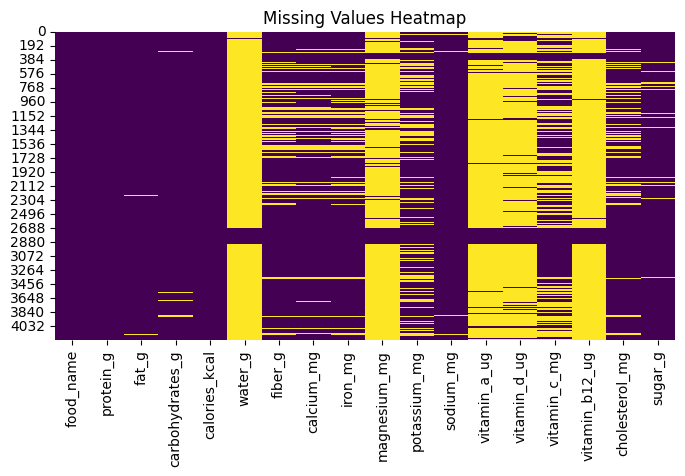

In [5]:
plt.figure(figsize=(8,4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

In [6]:
df = df.dropna() #remove the null value fields

In [7]:
df.shape

(244, 18)

In [8]:
df = df.drop_duplicates(subset='food_name')

In [9]:
df.shape

(243, 18)

In [10]:
df = df[df['food_name'].str.isalpha()]
df["food_name"] = df["food_name"].str.lower()

In [11]:
df.shape

(223, 18)

In [15]:
sns.set_style("whitegrid")

plt.rcParams['figure.figsize'] = (10,6)
plt.rcParams['font.size'] = 12

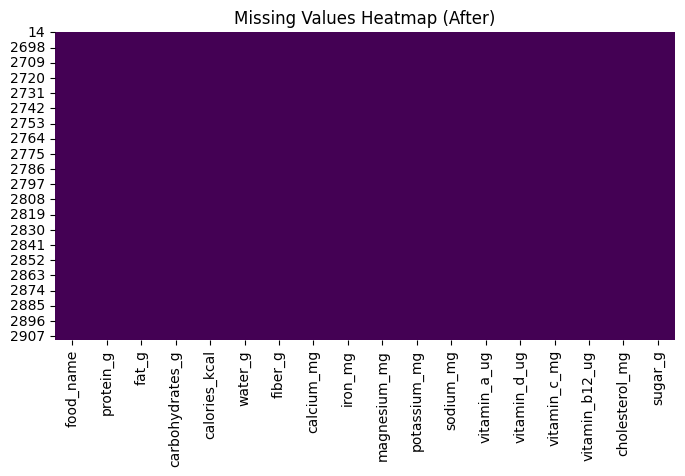

In [12]:
plt.figure(figsize=(8,4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap (After)")
plt.show()

In [13]:
df.to_csv("clean_food_dataset.csv", index=False)

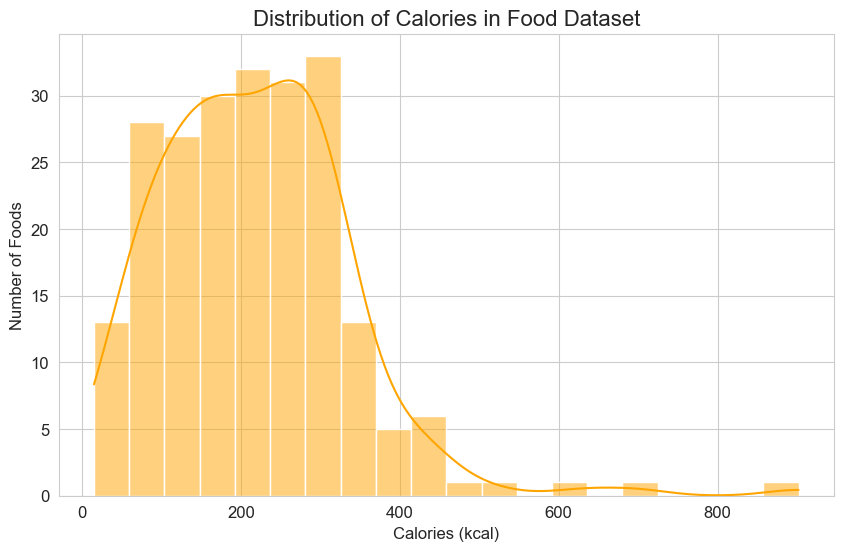

In [16]:
# Distribution of Calories
plt.figure()
sns.histplot(df['calories_kcal'], bins=20, kde=True, color='orange')
plt.title("Distribution of Calories in Food Dataset", fontsize=16)
plt.xlabel("Calories (kcal)", fontsize=12)
plt.ylabel("Number of Foods", fontsize=12)
plt.grid(True)
plt.show()

C:\Users\jatin koshti\AppData\Local\Temp\ipykernel_18620\2226752433.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


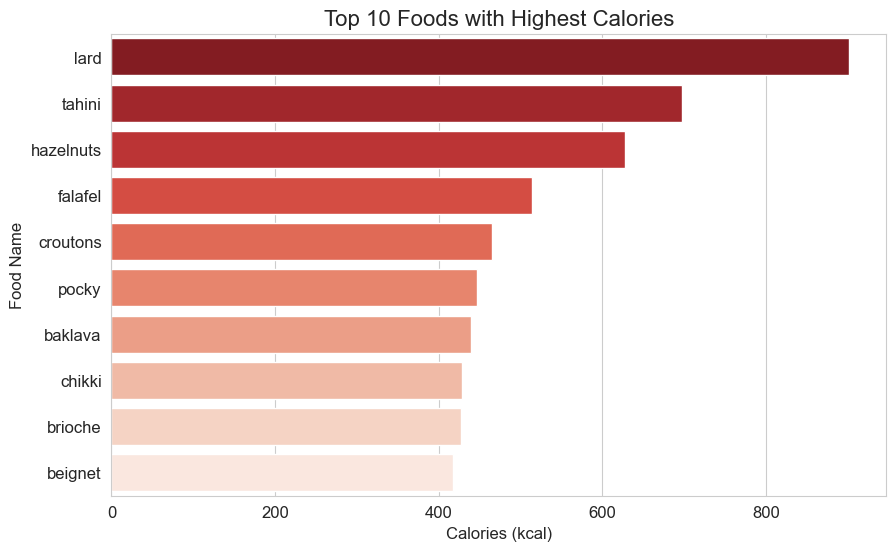

In [17]:
# Top 10 High Calorie Foods
top_foods = df.sort_values(by='calories_kcal', ascending=False).head(10)
plt.figure()
sns.barplot(
    x='calories_kcal',
    y='food_name',
    data=top_foods,
    palette="Reds_r"
)
plt.title("Top 10 Foods with Highest Calories", fontsize=16)
plt.xlabel("Calories (kcal)", fontsize=12)
plt.ylabel("Food Name", fontsize=12)
plt.show()

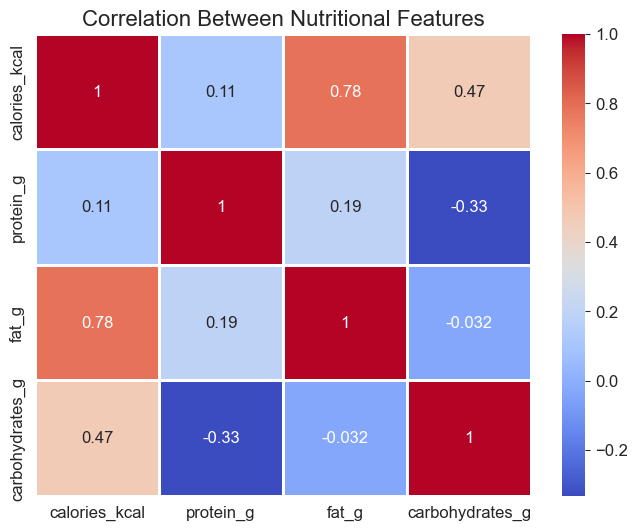

In [18]:
# Nutrition Correlation Heatmap
plt.figure(figsize=(8,6))
corr = df[['calories_kcal','protein_g','fat_g','carbohydrates_g']].corr()
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    linewidths=1
)
plt.title("Correlation Between Nutritional Features", fontsize=16)
plt.show()

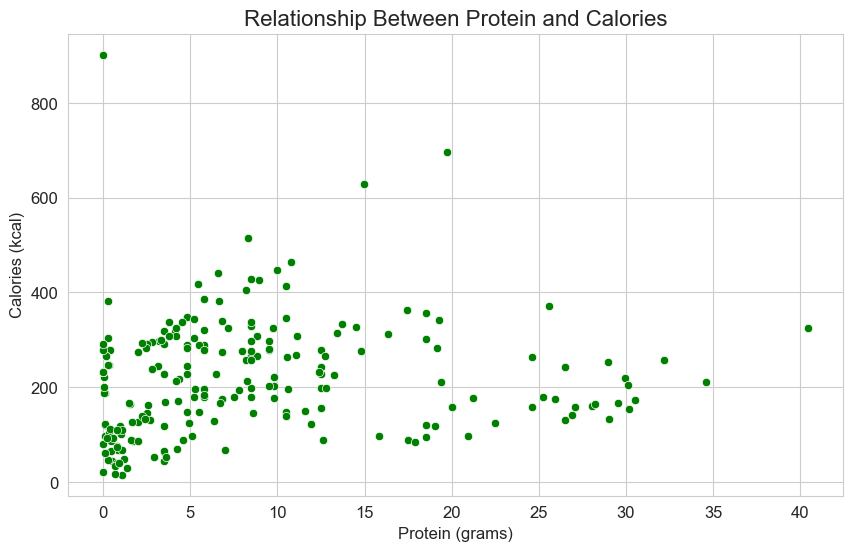

In [19]:
# Protein vs Calories
plt.figure()
sns.scatterplot(
    x='protein_g',
    y='calories_kcal',
    data=df,
    color='green'
)
plt.title("Relationship Between Protein and Calories", fontsize=16)
plt.xlabel("Protein (grams)", fontsize=12)
plt.ylabel("Calories (kcal)", fontsize=12)
plt.grid(True)
plt.show()

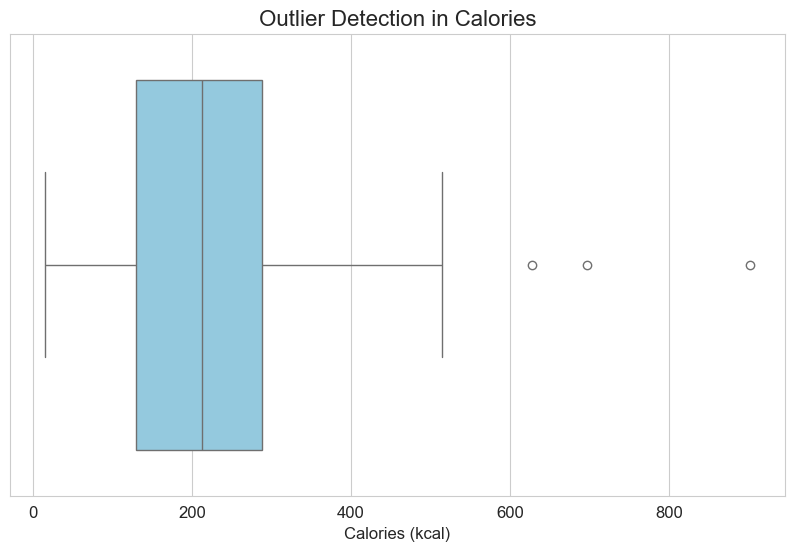

In [19]:
#Outlier Detection
plt.figure()
sns.boxplot(
    x=df['calories_kcal'],
    color='skyblue'
)
plt.title("Outlier Detection in Calories", fontsize=16)
plt.xlabel("Calories (kcal)", fontsize=12)
plt.show()

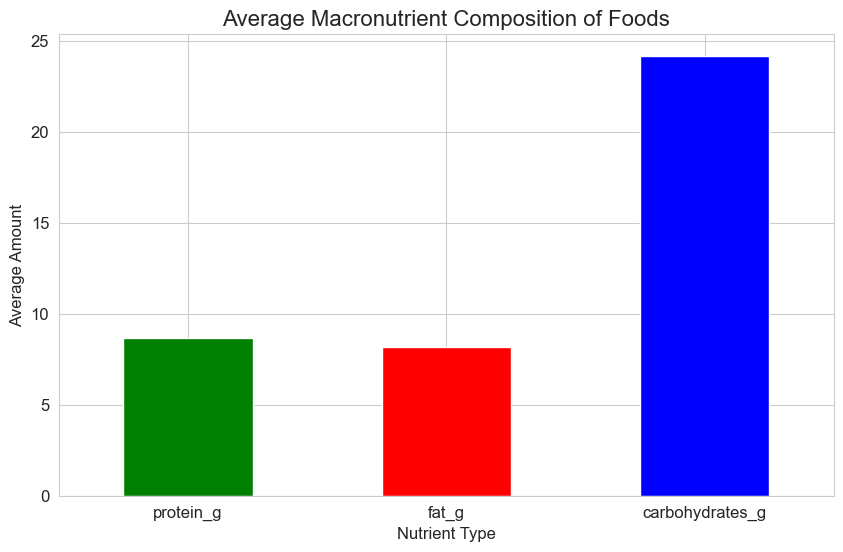

In [20]:
# Average Nutrient Comparison
nutrients = df[['protein_g','fat_g','carbohydrates_g']].mean()

plt.figure()

nutrients.plot(
    kind='bar',
    color=['green','red','blue']
)

plt.title("Average Macronutrient Composition of Foods", fontsize=16)
plt.xlabel("Nutrient Type", fontsize=12)
plt.ylabel("Average Amount", fontsize=12)

plt.xticks(rotation=0)

plt.show()

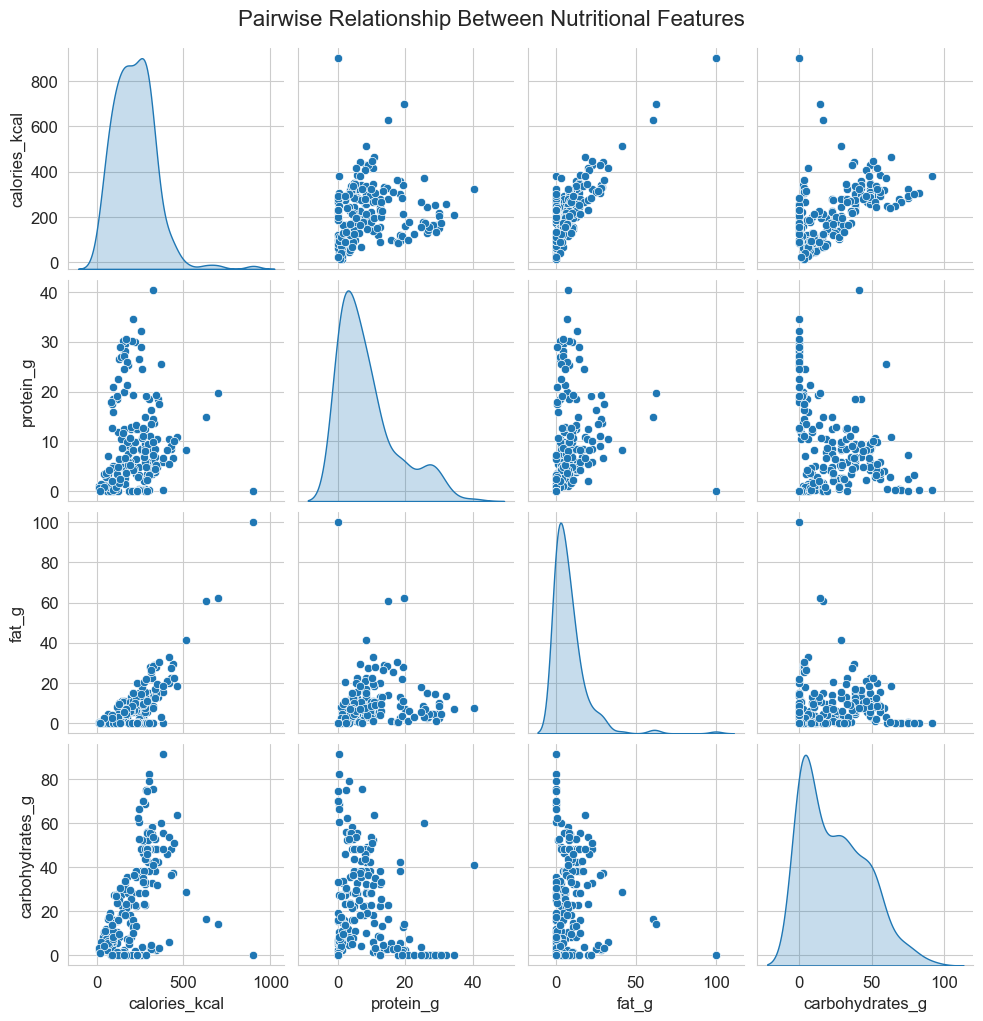

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
#Pairplot (Understand Feature Relationships)
sns.pairplot(
    df[['calories_kcal','protein_g','fat_g','carbohydrates_g']],
    diag_kind='kde'
)

plt.suptitle(
    "Pairwise Relationship Between Nutritional Features",
    fontsize=16,
    y=1.02
)

plt.show()

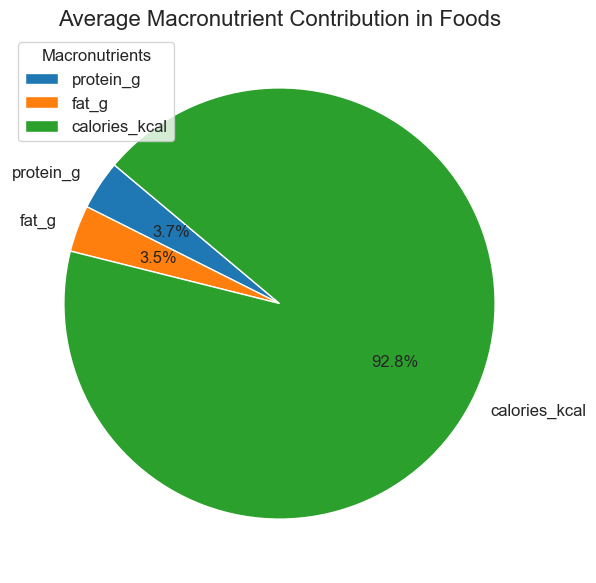

In [22]:
#Nutrient Contribution Pie Chart
nutrient_avg = df[['protein_g','fat_g','calories_kcal']].mean()

plt.figure(figsize=(7,7))

plt.pie(
    nutrient_avg,
    labels=nutrient_avg.index,
    autopct='%1.1f%%',
    startangle=140
)

plt.title(
    "Average Macronutrient Contribution in Foods",
    fontsize=16
)

plt.legend(
    title="Macronutrients",
    loc="best"
)

plt.show()

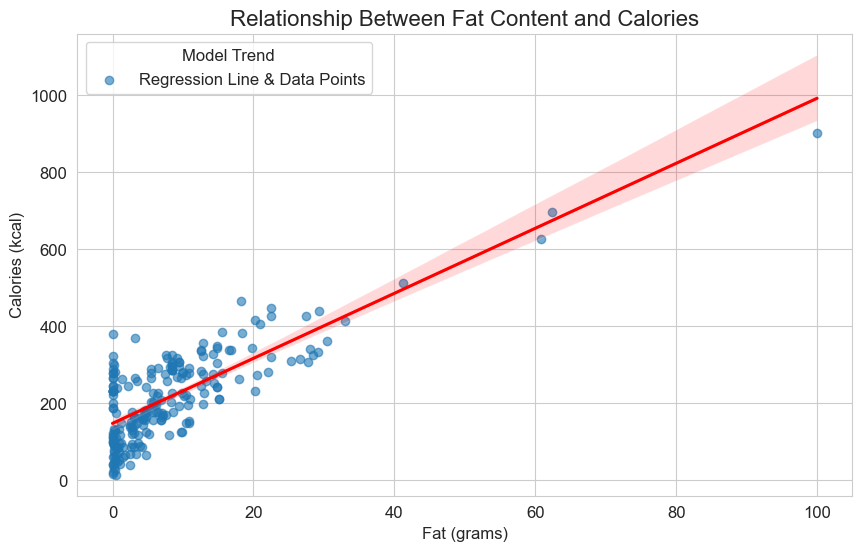

In [23]:
#Calories vs Fat Regression Plot
plt.figure(figsize=(10,6))

sns.regplot(
    x='fat_g',
    y='calories_kcal',
    data=df,
    scatter_kws={'alpha':0.6},
    line_kws={'color':'red'}
)

plt.title(
    "Relationship Between Fat Content and Calories",
    fontsize=16
)

plt.xlabel("Fat (grams)", fontsize=12)
plt.ylabel("Calories (kcal)", fontsize=12)

plt.legend(
    ["Regression Line & Data Points"],
    title="Model Trend"
)

plt.grid(True)

plt.show()

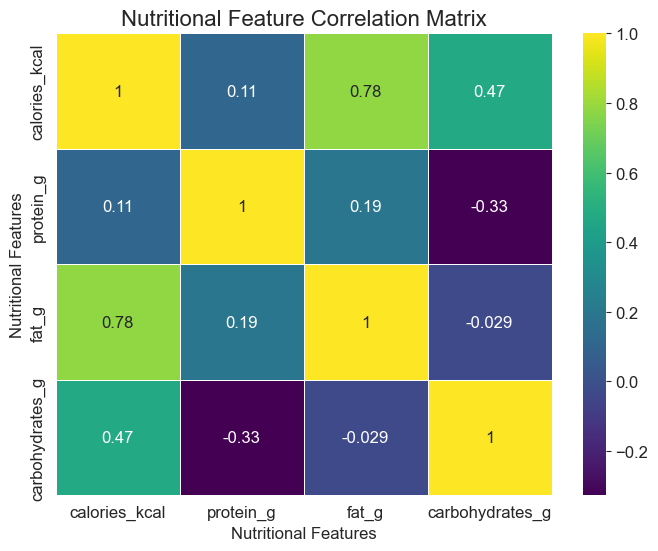

In [35]:
#Feature Correlation Heatmap (Improved)
plt.figure(figsize=(8,6))

corr_matrix = df[['calories_kcal','protein_g','fat_g','carbohydrates_g']].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='viridis',
    linewidths=0.5
)

plt.title(
    "Nutritional Feature Correlation Matrix",
    fontsize=16
)

plt.xlabel("Nutritional Features")
plt.ylabel("Nutritional Features")

plt.show()

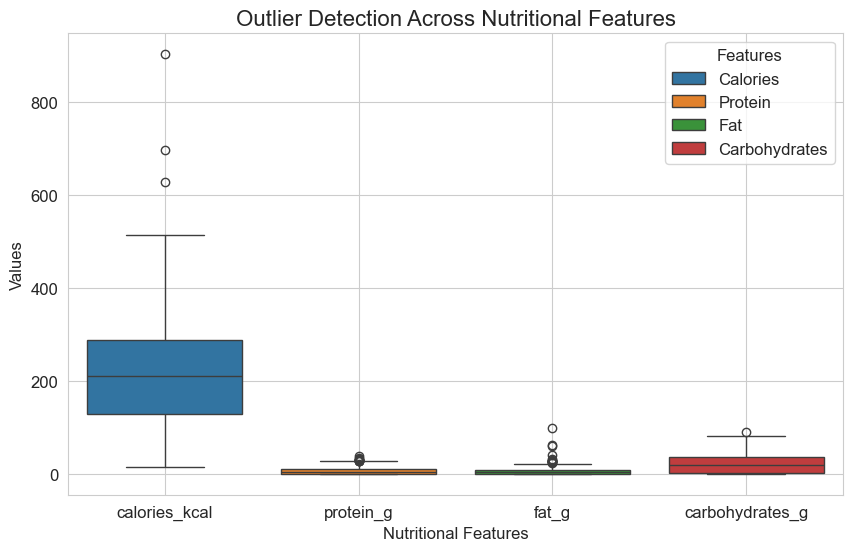

In [36]:
#Box Plot for All Nutrients
plt.figure(figsize=(10,6))

sns.boxplot(data=df[['calories_kcal','protein_g','fat_g','carbohydrates_g']])

plt.title(
    "Outlier Detection Across Nutritional Features",
    fontsize=16
)

plt.xlabel("Nutritional Features", fontsize=12)
plt.ylabel("Values", fontsize=12)

plt.legend(
    ['Calories','Protein','Fat','Carbohydrates'],
    title="Features"
)

plt.grid(True)

plt.show()